<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/AN%C3%81LISIS_DE_CORRELACI%C3%93N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv('amazon.csv')

In [31]:
#Exploracion
df.head() #Esto muestra las primeras filas de la tabla para ver las columnas.
df.info() #cuántas columnas hay y qué tipo de datos tiene cada columna
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   Category            128975 non-null  object 
 9   Size                128975 non-null  object 
 10  Courier Status      128975 non-null  object 
 11  Qty                 128975 non-null  int64  
 12  currency            128975 non-null  object 
 13  Amount              128975 non-null  float64
 14  ship-city           128975 non-null  object 
 15  ship-state          128975 non-nul

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,128975.000000,128975.000000
mean,64487.000000,0.904431,609.363662,463847.524466
std,37232.019822,0.313354,313.347147,191596.021199
min,0.000000,0.000000,0.000000,0.000000
25%,32243.500000,1.000000,413.000000,382421.000000
50%,64487.000000,1.000000,583.000000,500033.000000
75%,96730.500000,1.000000,771.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [40]:
#Limpieza basica
df = df.fillna(0)
print("Cantidad de valores nulos por columna después de rellenar con 0:")
display(df.isnull().sum())

#Borrado de columnas irrelevantes
df = df.drop(columns=['Order ID','SKU', 'Unnamed: 22', 'ASIN'])
print("DataFrame después de eliminar las columnas 'Order ID ''SKU','Unnamed: 22' y 'ASIN':")
df.info()

Cantidad de valores nulos por columna después de rellenar con 0:


,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
Category,0
Size,0


KeyError: "['SKU', 'Unnamed: 22', 'ASIN'] not found in axis"

In [33]:
#Identificación del Target
target = "Amount"
print(f"La variable objetivo (target) es: {target}")


La variable objetivo (target) es: Amount


Amount representa el monto total de la venta y es la variable que queremos explicar.

In [34]:
# Seleccionamos únicamente las variables numéricas
numeric_df = df.select_dtypes(include="number")
numeric_df

,index,Qty,Amount,ship-postal-code
0,0,0,647.62,400081.0
1,1,1,406.00,560085.0
2,2,1,329.00,410210.0
3,3,0,753.33,605008.0
4,4,1,574.00,600073.0
...,...,...,...,...
128970,128970,1,517.00,500013.0
128971,128971,1,999.00,122004.0
128972,128972,1,690.00,500049.0
128973,128973,1,1199.00,389350.0


In [35]:
#Análisis de correlaciones
corr_matrix = numeric_df.corr(method="pearson")
corr_matrix

,index,Qty,Amount,ship-postal-code
index,1.000000,0.010621,0.039899,0.003727
Qty,0.010621,1.000000,0.391096,-0.010059
Amount,0.039899,0.391096,1.000000,-0.035247
ship-postal-code,0.003727,-0.010059,-0.035247,1.000000


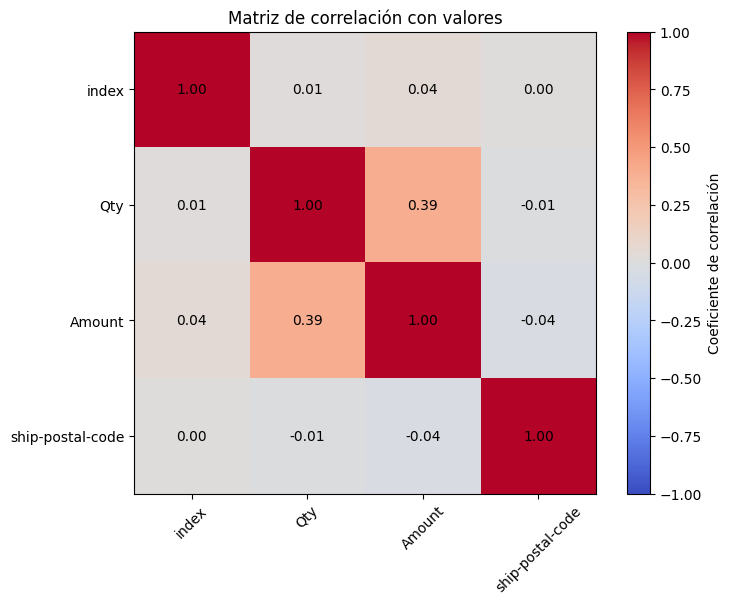

In [36]:
#Gráfica de correlación
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Coeficiente de correlación")

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Matriz de correlación con valores")
plt.show()

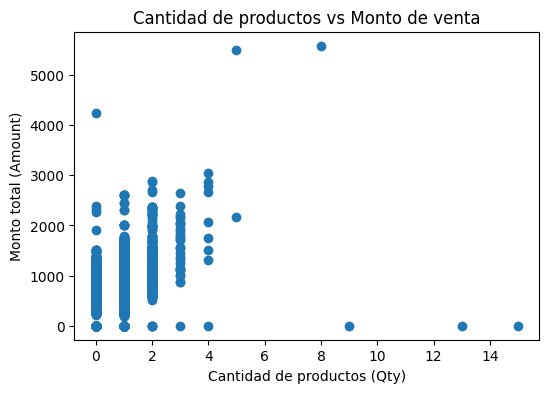

In [37]:
#Diagramas de dispersión
#Qty vs Amount
plt.figure(figsize=(6,4))
plt.scatter(data=df, x='Qty', y='Amount')

plt.title('Cantidad de productos vs Monto de venta')
plt.xlabel('Cantidad de productos (Qty)')
plt.ylabel('Monto total (Amount)')

plt.show()

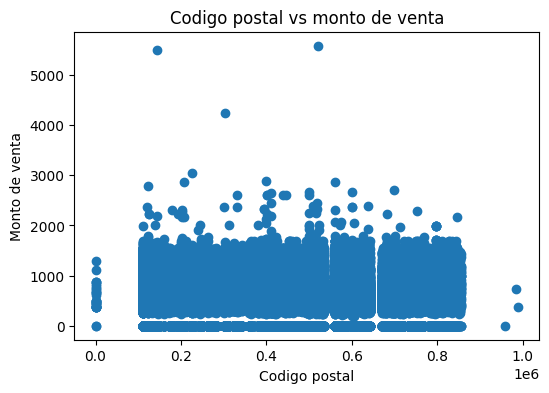

In [38]:
#Codigo postal vs Monto de venta

plt.figure(figsize=(6,4))

plt.scatter(data=df, x='ship-postal-code', y='Amount')

plt.title('Codigo postal vs monto de venta')
plt.xlabel('Codigo postal')
plt.ylabel('Monto de venta')

plt.show()


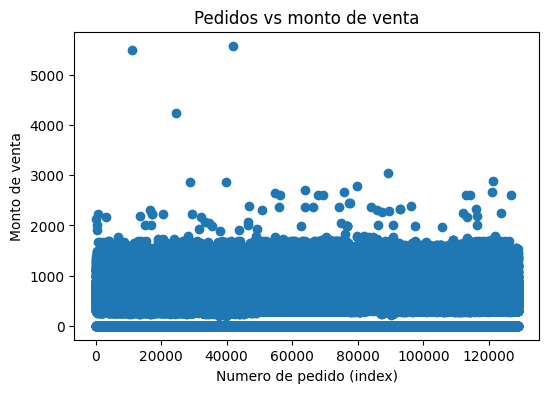

In [39]:
plt.figure(figsize=(6,4))

plt.scatter(df.index, df['Amount'])

plt.title('Pedidos vs monto de venta')
plt.xlabel('Numero de pedido (index)')
plt.ylabel('Monto de venta')

plt.show()

¿Qué variables están altamente correlacionadas con el target? Qty porque representa cuántos productos se compran
¿Qué variables para un modelo?
Podrían ser:Qty, B2B (tipo de cliente), Category y Size ya que estas influyen en el valor de la compra.
¿Por qué una alta correlación significa que una variable sea útil? Una alta correlación indica que dos variables tienen una relación fuerte. Esto significa que una variable puede ayudar a explicar o predecir el comportamiento de otra. En este caso, si la cantidad de productos comprados aumenta, es lógico que el monto total de la venta también aumente.
Interpretación crítica de resultados
El análisis de correlación muestra que la variable Qty tiene una relación positiva con el monto total de la venta (Amount). Esto indica que a mayor cantidad de productos comprados, mayor será el monto total de la compra. Otras variables como códigos postales no tienen una relación significativa con el monto de la venta.
Selección razonada de variables